# Iris flower classification

Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neural_network import Neural_Network

Dataset loading

In [2]:
iris = pd.read_csv("iris.csv")

First view

In [3]:
iris.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## What do we know our dataset ?

The iris dataset contains length and width mesurements of both sepal and petal for four species in centimeter.
* There are 150 rows and 5 columns provided in the data.
* No Null values exist.

## 1- Histogram visualization for distribution

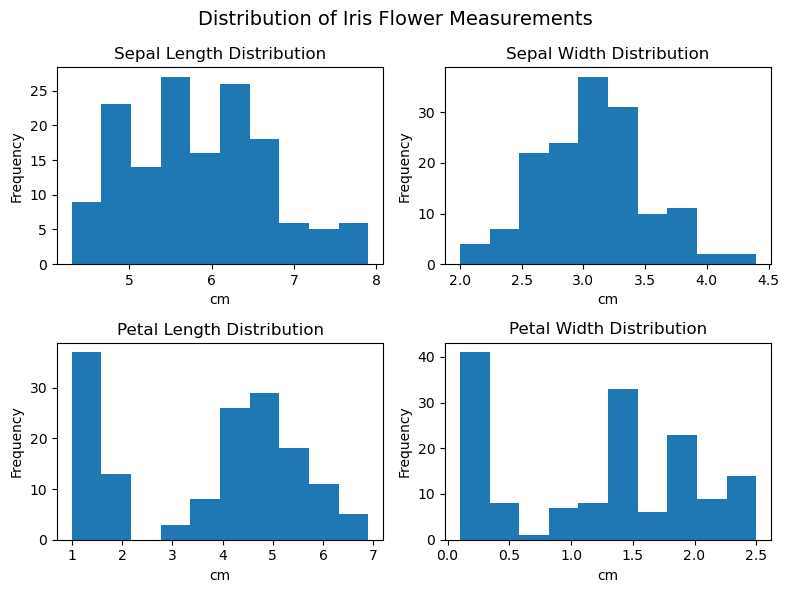

In [5]:
# Create a figure with subplots
plt.figure(figsize=(8, 6))
plt.suptitle('Distribution of Iris Flower Measurements', fontsize=14)

# Create a 2x2 grid of subplots
plt.subplot(2, 2, 1)  
plt.hist(iris['sepal.length'])
plt.title('Sepal Length Distribution')
plt.xlabel('cm')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)  
plt.hist(iris['sepal.width'])
plt.title('Sepal Width Distribution')
plt.xlabel('cm')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)  
plt.hist(iris['petal.length'])
plt.title('Petal Length Distribution')
plt.xlabel('cm')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4) 
plt.hist(iris['petal.width'])
plt.title('Petal Width Distribution')
plt.xlabel('cm')
plt.ylabel('Frequency')

# Display the subplots
plt.tight_layout()
plt.show()

## 2- Classification with scatter plot visualization 

In [6]:
colors = ['green', 'yellow', 'red']
varieties = iris['variety'].unique()

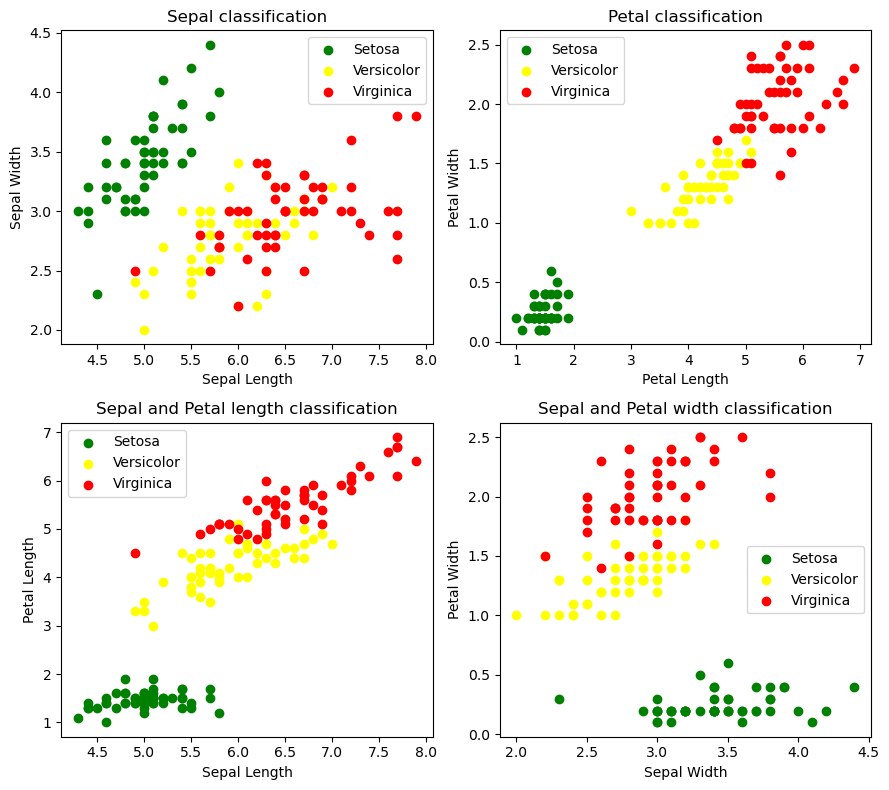

In [7]:
plt.figure(figsize=(9, 8))

plt.subplot(2, 2, 1) 
for i in range(len(varieties)):
    x = iris[iris['variety'] == varieties[i]]  #Splitting the rows into 3 groups (one for each variety)
    plt.scatter(x['sepal.length'], x['sepal.width'], color=colors[i], label=varieties[i])
    
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Sepal classification')
plt.legend()

plt.subplot(2, 2, 2) 
for i in range(len(varieties)):
    x = iris[iris['variety'] == varieties[i]]  
    plt.scatter(x['petal.length'], x['petal.width'], color=colors[i], label=varieties[i])
    
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal classification')
plt.legend()

plt.subplot(2, 2, 3) 
for i in range(len(varieties)):
    x = iris[iris['variety'] == varieties[i]]  
    plt.scatter( x['sepal.length'], x['petal.length'], color=colors[i], label=varieties[i])
    
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Sepal and Petal length classification')
plt.legend()

plt.subplot(2, 2, 4) 
for i in range(len(varieties)):
    x = iris[iris['variety'] == varieties[i]]  
    plt.scatter(x['sepal.width'], x['petal.width'], color=colors[i], label=varieties[i])
    
plt.xlabel('Sepal Width')
plt.ylabel('Petal Width')
plt.title('Sepal and Petal width classification')
plt.legend()

plt.tight_layout()
plt.show()

## 3- Data Preprocessing


In [8]:
# Defining the X (features) and y (labels)
X = iris.drop(columns=['variety'], axis=1).values.astype(float)
X = np.array(X)

# Labels encoding (0, 1, 2) for the 3 classes (Setosa, Versicolor, Virginica)
classes, y = np.unique(iris['variety'], return_inverse=True)

In [9]:
# Normalisation : Min-Max Normalisation to [0, 1]
X_min = np.min(X)
X_max = np.max(X)
X_norm = (X - X_min) / (X_max - X_min)

### Splitting the data into train and test

In [10]:
#Train test split (homemade)
np.random.seed(42)

#Initialisation
X_train, X_test = [], []
y_train, y_test = [], []

#Shuffle and split for every label (0, 1, 2)
for cls in np.unique(y):
    idx = np.where(y == cls)[0] #Get the indices of the current class
    np.random.shuffle(idx)      #Shuffle the indices

    split = int(0.8 * len(idx)) #80% for training, 20% for testing
    train_idx = idx[:split]
    test_idx = idx[split:]
    
    X_train.append(X_norm[train_idx])
    X_test.append(X_norm[test_idx])

    y_train.append(y[train_idx])
    y_test.append(y[test_idx])

# Concatenate the lists to form final arrays
X_train = np.concatenate(X_train)
X_test = np.concatenate(X_test)

y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)

In [11]:
#Function to one-hot encode the labels. Egg: 0 -> [1,0,0], 1 -> [0,1,0], 2 -> [0,0,1]
def encode_one_hot(y):
    y_encoded = pd.get_dummies(y).values.astype(float)
    return np.array(y_encoded)

y_train = encode_one_hot(y_train)
y_test = encode_one_hot(y_test)

In [12]:
# Checking the train distribution of each variety
print(np.bincount(np.argmax(y_test, axis=1)))

[10 10 10]


## 4- Model training and evaluation

In [46]:
NN = Neural_Network(input_size=4, hidden_size=7, output_size=3, learning_rate=0.01)

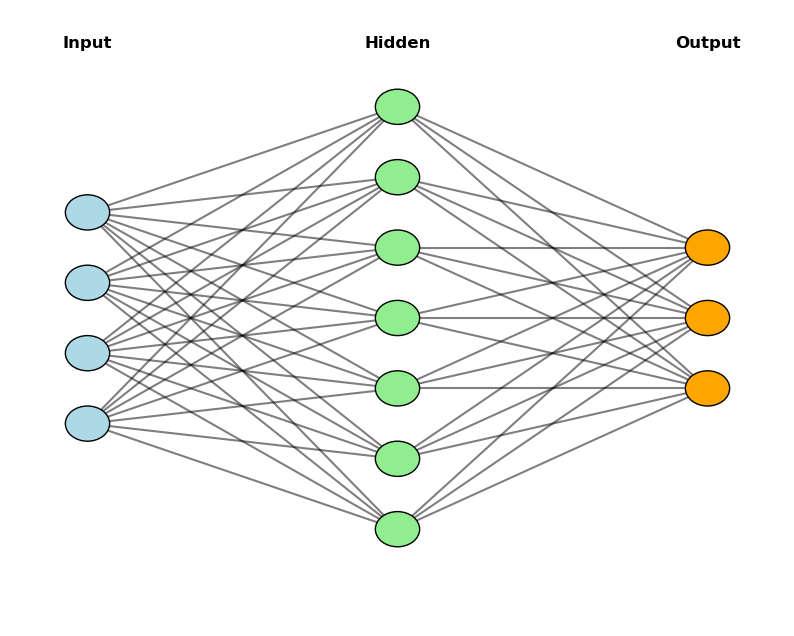

In [47]:
fig = plt.figure(figsize=(10, 8))
ax = fig.gca()
ax.axis('off')

NN.display(ax)

In [48]:
loss_tab = NN.train(X_train, y_train, epochs = 8000)

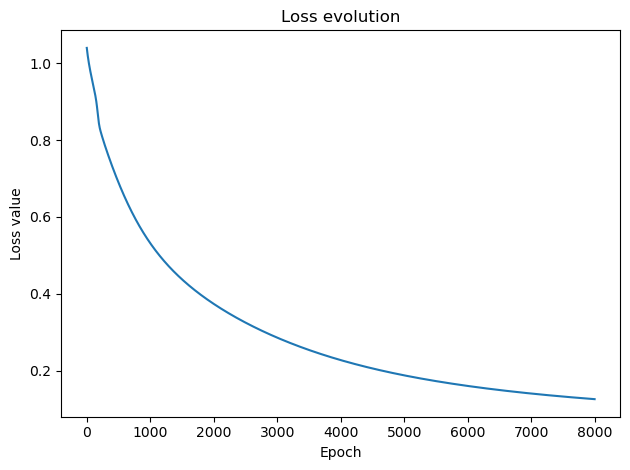

In [49]:
#Display the loss evolution
plt.plot(loss_tab)
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("Loss evolution")
plt.tight_layout()

In [50]:
#Accuracy
y_pred = NN.predict(X_test)

y_true = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred == y_true)
print(f"Accuracy : {accuracy*100:.2f} %")

Accuracy : 96.67 %


In [51]:
#Confusion matrix for detailed performance
def confusion_matrix(y, y_pred, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype = int)
    for t,p in zip(y, y_pred):
        matrix[t,p] += 1
    return matrix

cm = confusion_matrix(y_true, y_pred, num_classes = 3)
print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [52]:
def classification_report(y_true, y_pred, num_classes):
    report = {}
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
       
        precision = tp / (tp + fp + 1e-15)
        recall    = tp / (tp + fn + 1e-15)
        f1        = 2 * precision * recall / (precision + recall + 1e-15)
       
        report[c] = {
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1-score": round(f1, 4)
        }
    
    print(f"{'Class':<12}{'Precision':<10}{'Recall':<10}{'F1-score':<10}")
    print("-" * 42)
    classes = ['Setosa', 'Versicolor', 'Virginica']
    for cls in range(num_classes):
        metrics = report[cls]
        print(f"{classes[cls]:<12}{metrics['precision']:<10}{metrics['recall']:<10}{metrics['f1-score']:<10}")

classification_report(y_true, y_pred, num_classes = 3)

Class       Precision Recall    F1-score  
------------------------------------------
Setosa      1.0       1.0       1.0       
Versicolor  1.0       0.9       0.9474    
Virginica   0.9091    1.0       0.9524    
